In [1]:
!pip install polars

import polars as pl

In [11]:
mkdir /workspace/Thesis_updated_results/hierarchical_contrastive

In [2]:
import os
import random
import sys
import cv2
import tqdm
import json
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [3]:

!nvidia-smi

Sun Feb 15 21:34:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               On  |   00000000:D6:00.0 Off |                  Off |
| 33%   63C    P2            194W /  230W |    7899MiB /  24564MiB |     50%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
os.chdir('/workspace')

In [5]:
BASE_PATH = 'vindr_mammogram'
IMG_DIR = os.path.join(BASE_PATH, 'mammo_processed_merged1') 
csv_files = [f for f in os.listdir(IMG_DIR) if f.endswith('.csv')]

# Print results
if csv_files:
    print(f"Found {len(csv_files)} CSV file(s) in {IMG_DIR}:")
    for csv_file in csv_files:
        print(f"{csv_file}")
else:
    print(f"No CSV files found in {IMG_DIR}")


Found 1 CSV file(s) in vindr_mammogram/mammo_processed_merged1:
mammo_processed_merged.csv


In [6]:
df = pl.read_csv("vindr_mammogram/mammo_processed_merged1/mammo_processed_merged.csv")
df = df.to_pandas()
df["merged_image_path"] = (
    df["merged_image_path"]
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
    .str.replace("vindr_original_data", "vindr_mammogram", regex=False)
)
density_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

df['density'] = df['cc_breast_density'].str[-1].map(density_mapping)
df.head()



,study_id,laterality,merged_image_path,cc_image_id,mlo_image_id,split,cc_image_path,mlo_image_path,has_cc_bbox,has_mlo_bbox,...,mlo_crop_coords,cc_breast_birads,mlo_breast_birads,cc_breast_density,mlo_breast_density,cc_finding_categories,mlo_finding_categories,cc_finding_birads,mlo_finding_birads,density
0,0025a5dc99fd5c742026f0b2b030d3e9,L,vindr_mammogram/mammo_processed_merged1/0025a5...,451562831387e2822923204cf8f0873e,2ddfad7286c2b016931ceccd1e2c7bbc,test,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 992, 2443)",BI-RADS 1,BI-RADS 1,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
1,0025a5dc99fd5c742026f0b2b030d3e9,R,vindr_mammogram/mammo_processed_merged1/0025a5...,fcf12c2803ba8dc564bf1287c0c97d9a,47c8858666bcce92bcbd57974b5ce522,test,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(11, 0, 1064, 2560)",BI-RADS 1,BI-RADS 1,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
2,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,L,vindr_mammogram/mammo_processed_merged1/0028fb...,3704f91985dcbc69f6ac2803523d1ecb,7fc1f1bb8bb1a7efaf7104e49c4d8b86,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 935, 2486)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
3,0028fb2c7f0b3a5cb9a80cb0e1cdbb91,R,vindr_mammogram/mammo_processed_merged1/0028fb...,c4ce68631bf70949570ded31a3c69e60,16e58fc1d65fa7587247e6224ee96527,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(13, 0, 953, 2508)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2
4,0034765af074f93ed33d5e8399355caf,L,vindr_mammogram/mammo_processed_merged1/003476...,68f09c18925a66ef2840d4a62f237b31,b664cf1e7c968896144a3a2005cd3eb4,training,vindr_original_data/mammo_processed_cropped/00...,vindr_original_data/mammo_processed_cropped/00...,False,False,...,"(0, 0, 961, 2802)",BI-RADS 2,BI-RADS 2,DENSITY C,DENSITY C,['No Finding'],['No Finding'],NaN,NaN,2


In [7]:
def get_combined_finding_5class(cc_findings, mlo_findings):
    """
    Optimized 5-class classification based on your requirements:
    
    PRIORITY ORDER (highest to lowest):
    1. Skin/Nipple/Architectural Distortion → Class 3 (always high suspicion)
    2. Mass + Calcifications together → Class 4 (highest suspicion combo)
    3. Mass only → Class 2
    4. Calcifications only → Class 1
    5. Pure Asymmetry only → DROP (-1)
    6. No Finding → Class 0
    
    Rationale:
    - Class 4 (Mass+Calc): Combined findings indicate complex malignant lesions
    - Class 3 (Arch Dist/Skin): Structural changes highly suspicious for cancer
    - Class 2 (Mass): Moderate-high suspicion, most common malignant finding
    - Class 1 (Calc): Variable suspicion, needs assessment
    - Class 0: Benign/Normal
    """
    # Parse findings
    if isinstance(cc_findings, str):
        cc_findings = eval(cc_findings) if cc_findings else []
    if isinstance(mlo_findings, str):
        mlo_findings = eval(mlo_findings) if mlo_findings else []
    
    cc_findings = cc_findings or []
    mlo_findings = mlo_findings or []
    all_findings = set(cc_findings + mlo_findings)
    
    # Remove 'No Finding' if other findings present
    if len(all_findings) > 1 and 'No Finding' in all_findings:
        all_findings.remove('No Finding')
    
    # Define finding groups
    high_suspicion_structural = {
        'Architectural Distortion',
        'Skin Thickening',
        'Skin Retraction',
        'Nipple Retraction'
    }
    
    asymmetry_findings = {
        'Focal Asymmetry',
        'Global Asymmetry',
        'Asymmetry'
    }
    
    # Check key findings
    has_mass = 'Mass' in all_findings
    has_calc = 'Suspicious Calcification' in all_findings
    has_structural = bool(all_findings & high_suspicion_structural)
    has_asymmetry = bool(all_findings & asymmetry_findings)
    has_lymph = 'Suspicious Lymph Node' in all_findings
    
    # Classification Logic
    
    # Class 0: No Finding
    if not all_findings or all_findings == {'No Finding'}:
        return 0
    
    # PRIORITY 1: Class 3 - High Suspicion Structural Changes
    # Any architectural distortion or skin/nipple changes
    if has_structural:
        return 3
    
    # PRIORITY 2: Class 4 - Combined Mass + Calcifications (Highest Suspicion)
    # This combination often indicates malignant lesions with microcalcifications
    if has_mass and has_calc:
        return 4
    
    # PRIORITY 3: Class 2 - Mass Only
    if has_mass:
        return 2
    
    # PRIORITY 4: Class 1 - Calcifications Only
    if has_calc:
        return 1
    
    # PRIORITY 5: Suspicious Lymph Node
    # Treat as high suspicion (often metastatic involvement)
    if has_lymph:
        return 3
    
    # PRIORITY 6: Pure Asymmetry Cases - DROP
    # These are ambiguous and mostly require additional imaging, not biopsys
    if has_asymmetry and len(all_findings) == 1:
        return 6  # Will be dropped
    
    # PRIORITY 7: Asymmetry + Other Findings
    # If asymmetry is combined with something else (rare), treat as high suspicion
    if has_asymmetry and len(all_findings) > 1:
        return 3
    
    # Fallback for unknown findings (shouldn't happen with your data)
    print(f"Warning: Unknown finding combination: {all_findings}")
    return 3  


df['finding'] = df.apply(
    lambda row: get_combined_finding_5class(row['cc_finding_categories'], row['mlo_finding_categories']),
    axis=1
)
df.drop(df[df['finding'] == -1].index, inplace=True)
df['finding'].value_counts()

finding
0    9032
2     490
6     189
1     132
3      95
4      61
Name: count, dtype: int64

In [8]:
inbreast_df = pd.read_csv("inbreast_data/INbreast_merged/merged_metadata.csv")
inbreast_df["merged_image_path"] = (
    inbreast_df["merged_image_path"]
    .str.replace("INbreast Release 1.0", "inbreast_data", regex=False)
    .str.replace("vindr_original_data", "inbreast_data", regex=False))
inbreast_df['birads'] = inbreast_df['birads'].replace({'4a': '4', '4b': '4', '4c': '4'})
def birads_to_binary(birads):
    return 0 if birads in ['1'] else 1 
inbreast_df['label'] = inbreast_df['birads'].apply(birads_to_binary)
inbreast_df['density'] = 0
inbreast_df = inbreast_df.rename(columns={"patient_id": "study_id"})

inbreast_df.head(5)

,study_id,laterality,merged_image_path,cc_file_name,mlo_file_name,cc_image_path,mlo_image_path,birads,cc_roi_width,cc_roi_height,mlo_roi_width,mlo_roi_height,label,density
0,024ee3569b2605dc,L,inbreast_data/INbreast_merged/024ee3569b2605dc...,20588020,20588072,INbreast Release 1.0/INbreast_processed/205880...,INbreast Release 1.0/INbreast_processed/205880...,2,1557,3231,1674,3192,1,0
1,024ee3569b2605dc,R,inbreast_data/INbreast_merged/024ee3569b2605dc...,20587994,20588046,INbreast Release 1.0/INbreast_processed/205879...,INbreast Release 1.0/INbreast_processed/205880...,6,1535,3128,1775,3199,1,0
2,069212ec65a94339,L,inbreast_data/INbreast_merged/069212ec65a94339...,50994787,50994733,INbreast Release 1.0/INbreast_processed/509947...,INbreast Release 1.0/INbreast_processed/509947...,1,1226,2580,1340,3193,0,0
3,069212ec65a94339,R,inbreast_data/INbreast_merged/069212ec65a94339...,50994706,50994760,INbreast Release 1.0/INbreast_processed/509947...,INbreast Release 1.0/INbreast_processed/509947...,1,1128,2566,1177,3195,0,0
4,0b7396cdccacca82,L,inbreast_data/INbreast_merged/0b7396cdccacca82...,22670832,22670878,INbreast Release 1.0/INbreast_processed/226708...,INbreast Release 1.0/INbreast_processed/226708...,2,1627,2983,1598,3170,1,0


In [9]:
n_studies = inbreast_df['study_id'].nunique()
print("Total unique studies:", n_studies)


Total unique studies: 107


In [10]:
rows_per_study = inbreast_df.groupby('study_id').size()
rows_per_study.value_counts().sort_index()


1    27
2    80
Name: count, dtype: int64

In [11]:
studies_1 = rows_per_study[rows_per_study == 1].index
df_1 = inbreast_df[inbreast_df['study_id'].isin(studies_1)].copy()

df_1.head()


,study_id,laterality,merged_image_path,cc_file_name,mlo_file_name,cc_image_path,mlo_image_path,birads,cc_roi_width,cc_roi_height,mlo_roi_width,mlo_roi_height,label,density
6,0c735e8768d276b4,R,inbreast_data/INbreast_merged/0c735e8768d276b4...,50995789,50995762,INbreast Release 1.0/INbreast_processed/509957...,INbreast Release 1.0/INbreast_processed/509957...,2,1222,2837,1373,3008,1,0
7,11e6732579acf692,L,inbreast_data/INbreast_merged/11e6732579acf692...,53587599,53587572,INbreast Release 1.0/INbreast_processed/535875...,INbreast Release 1.0/INbreast_processed/535875...,2,2067,3719,2120,4031,1,0
10,1e4b534393d18753,R,inbreast_data/INbreast_merged/1e4b534393d18753...,50998349,50998322,INbreast Release 1.0/INbreast_processed/509983...,INbreast Release 1.0/INbreast_processed/509983...,1,971,2736,1521,3150,0,0
11,1e5c3af078f74b05,L,inbreast_data/INbreast_merged/1e5c3af078f74b05...,22614236,22614266,INbreast Release 1.0/INbreast_processed/226142...,INbreast Release 1.0/INbreast_processed/226142...,5,1390,2795,1457,2994,1,0
24,330e5fe16929eed4,R,inbreast_data/INbreast_merged/330e5fe16929eed4...,50996736,50996709,INbreast Release 1.0/INbreast_processed/509967...,INbreast Release 1.0/INbreast_processed/509967...,2,1860,2770,1852,3086,1,0


In [12]:
def birads_to_binary(birads):
    return 0 if birads in ['BI-RADS 1'] else 1 
df['label'] = df['cc_breast_birads'].apply(birads_to_binary)

In [13]:
df['cc_breast_birads'].value_counts()

cc_breast_birads
BI-RADS 1    6703
BI-RADS 2    2337
BI-RADS 3     465
BI-RADS 4     381
BI-RADS 5     113
Name: count, dtype: int64

In [14]:
df['cc_breast_density'].value_counts()

cc_breast_density
DENSITY C    7645
DENSITY D    1350
DENSITY B     954
DENSITY A      50
Name: count, dtype: int64

In [15]:
data = df[df['split'] == 'training']
test_df = df[df['split'] == 'test']

In [16]:
from sklearn.model_selection import train_test_split


study_meta = (
    data
    .groupby('study_id')
    .agg({
        'cc_breast_birads': 'first',   # BI-RADS at study level
        'finding': 'first'             # finding already encoded as 0–4
    })
    .reset_index()
)


# -------------------------------------------------
study_meta['stratify_key'] = (
    study_meta['cc_breast_birads'].astype(str) + '_' +
    study_meta['finding'].astype(str)
)


train_studies, val_studies = train_test_split(
    study_meta['study_id'],
    test_size=0.1,
    stratify=study_meta['stratify_key'],
    random_state=423
)

train_df = data[data['study_id'].isin(train_studies)].copy()
val_df   = data[data['study_id'].isin(val_studies)].copy()


In [17]:
train_df['density'].value_counts()

density
2    5504
3     967
1     693
0      36
Name: count, dtype: int64

In [18]:
val_df['density'].value_counts()

density
2    611
3    113
1     71
0      4
Name: count, dtype: int64

In [19]:
train_df.shape

(7200, 27)

In [20]:
train_df.columns

Index(['study_id', 'laterality', 'merged_image_path', 'cc_image_id',
       'mlo_image_id', 'split', 'cc_image_path', 'mlo_image_path',
       'has_cc_bbox', 'has_mlo_bbox', 'merged_cc_bbox', 'merged_mlo_bbox',
       'original_cc_bbox', 'original_mlo_bbox', 'cc_crop_coords',
       'mlo_crop_coords', 'cc_breast_birads', 'mlo_breast_birads',
       'cc_breast_density', 'mlo_breast_density', 'cc_finding_categories',
       'mlo_finding_categories', 'cc_finding_birads', 'mlo_finding_birads',
       'density', 'finding', 'label'],
      dtype='str')

In [21]:
import numpy as np
import cv2
from PIL import Image
import torchvision.transforms as transforms
import random
import torch


def get_transforms(img_size=(512, 512)):
    """Enhanced mammogram preprocessing with medical imaging considerations"""
    
    train_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        
        transforms.RandomApply([
            transforms.RandomAffine(
                degrees=10,
                translate=(0.1, 0.1),
                scale=(0.9, 1.1),
                shear=6
            )
        ], p=0.6),
        
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([
            transforms.RandomPerspective(distortion_scale=0.1, p=1.0)
        ], p=0.1),
        
        transforms.RandomApply([
            transforms.ElasticTransform(alpha=5.0, sigma=3.0)
        ], p=0.2),
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=(0.95, 1.05),
                contrast=(0.9, 1.1)
            )
        ], p=0.4),
        transforms.Lambda(lambda x: adjust_gamma(x, gamma=random.uniform(0.8, 1.2)) 
                         if random.random() < 0.4 else x),
        

        
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
        ], p=0.2),
        
                # NOISE AUGMENTATIONS
        transforms.Lambda(lambda x: add_gaussian_noise(x, mean=0, std=random.uniform(0.001, 0.02)) 
                         if random.random() < 0.4 else x),
        
        transforms.Lambda(lambda x: add_speckle_noise(x, std=random.uniform(0.01, 0.03)) 
                         if random.random() < 0.2 else x),
        transforms.ToTensor(),
        
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize(img_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    return train_transform, val_transform

def add_gaussian_noise(image, mean=0, std=0.02):
    """Gaussian noise - electronic noise in imaging sensors"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(mean, std, img_array.shape)
        noisy_img = np.clip(img_array + noise, 0, 1)
        return Image.fromarray((noisy_img * 255).astype(np.uint8))
    return image


def add_speckle_noise(image, std=0.03):
    """Speckle noise - multiplicative noise common in mammography"""
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        noise = np.random.normal(0, std, img_array.shape)
        noisy_img = img_array + img_array * noise
        return Image.fromarray((np.clip(noisy_img, 0, 1) * 255).astype(np.uint8))
    return image

def adjust_gamma(image, gamma=1.0):
    """
    Gamma correction - handles tissue density variation
    Gamma < 1 = brighter, > 1 = darker
    """
    if isinstance(image, Image.Image):
        img_array = np.array(image).astype(np.float32) / 255.0
        gamma_corrected = np.power(img_array, gamma)
        return Image.fromarray((gamma_corrected * 255).astype(np.uint8))
    return image

In [22]:
import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import pandas as pd
from PIL import Image
import os
from torchvision import transforms
import matplotlib.pyplot as plt
# import albumentations as A
# from albumentations.pytorch import ToTensorV2
import random

import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import pandas as pd
from PIL import Image
import os
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_v2_m, EfficientNet_V2_M_Weights
import time
import gc
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau


class VinDrMammoDataset(Dataset):
    def __init__(self, dataframe, transform=None, mode='train'):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.mode = mode
        
        valid_study_ids = []
        study_combined_labels = []
        normal_count = 0
        malignant_count = 0
        problematic_studies = []
        
        for study_id in self.dataframe['study_id'].unique():
            rows = self.dataframe[self.dataframe['study_id'] == study_id]
            
            left_rows = rows[rows['laterality'] == 'L']
            right_rows = rows[rows['laterality'] == 'R']
            
            if left_rows.empty or right_rows.empty:
                problematic_studies.append((study_id, "Missing laterality"))
                continue
                
            left_path = left_rows.iloc[0]['merged_image_path']
            right_path = right_rows.iloc[0]['merged_image_path']
            
            if not os.path.exists(left_path):
                problematic_studies.append((study_id, f"Missing file: {left_path}"))
                continue
            if not os.path.exists(right_path):
                problematic_studies.append((study_id, f"Missing file: {right_path}"))
                continue
            
            valid_study_ids.append(study_id)
            
            label_L = left_rows.iloc[0]['label']
            label_R = right_rows.iloc[0]['label']
            combined_label = 1 if label_L == 1 or label_R == 1 else 0
            study_combined_labels.append(combined_label)
            
            if combined_label == 0:
                normal_count += 1
            else:
                malignant_count += 1
        
        if problematic_studies:
            print(f"\n{mode.capitalize()} Dataset: {len(problematic_studies)} studies excluded due to missing sides or files:")
            for sid, reason in problematic_studies[:20]:
                print(f"   - {sid}: {reason}")
            if len(problematic_studies) > 20:
                print(f"   ... and {len(problematic_studies)-20} more.")
        
        self.study_ids = valid_study_ids
        self.study_combined_labels = study_combined_labels
        
        print(f"{mode.capitalize()} Dataset - Valid Studies: {len(self)} (Normal: {normal_count}, Malignant: {malignant_count})")
    
    def __len__(self):
        return len(self.study_ids)
    
    def __getitem__(self, idx):
        study_id = self.study_ids[idx]
        rows = self.dataframe[self.dataframe['study_id'] == study_id]
        
        row_L = rows[rows['laterality'] == 'L'].iloc[0]
        row_R = rows[rows['laterality'] == 'R'].iloc[0]
        
        image_L = Image.open(row_L['merged_image_path']).convert('RGB')
        image_R = Image.open(row_R['merged_image_path']).convert('RGB')
        
        if self.transform:
            # image_L=np.array(image_L)
            # image_R=np.array(image_R)
            # transformed = self.transform(image=image_L, image2=image_R)
            # image_L_tensor = transformed['image']
            # image_R_tensor = transformed['image2']
            image_L_tensor = self.transform(image_L)
            image_R_tensor = self.transform(image_R)
        else:
            image_L_tensor = transforms.ToTensor()(image_L)
            image_R_tensor = transforms.ToTensor()(image_R)
        
        label_L = row_L['label']
        label_R = row_R['label']
        combined_label = 1 if label_L == 1 or label_R == 1 else 0
        
        finding_L = row_L.get('finding', 0)
        finding_R = row_R.get('finding', 0)
        finding = min(finding_L, finding_R) if finding_L != 0 and finding_R != 0 else (finding_L or finding_R or 0)
        
        density_L = row_L.get('density', 0)
        density_R = row_R.get('density', 0)
        density = max(density_L, density_R)
        
        return (
            image_R_tensor, image_L_tensor,
            torch.tensor(label_R, dtype=torch.long),
            torch.tensor(label_L, dtype=torch.long),
            torch.tensor(combined_label, dtype=torch.long),
            torch.tensor(finding, dtype=torch.long),
            torch.tensor(density, dtype=torch.long)
        )

def create_data_loaders(train_df, val_df, test_df, inbreast_df, batch_size=4, img_size=(512, 512)):
    train_transform, val_transform = get_transforms(img_size)
    
    train_dataset = VinDrMammoDataset(train_df, transform=train_transform, mode='train')
    val_dataset   = VinDrMammoDataset(val_df,   transform=val_transform,   mode='val')
    test_dataset  = VinDrMammoDataset(test_df,  transform=val_transform,   mode='test')
    inbreast_dataset = VinDrMammoDataset(inbreast_df, transform=val_transform, mode='inbreast')
    
    combined_labels = np.array(train_dataset.study_combined_labels)
    unique_classes, class_counts = np.unique(combined_labels, return_counts=True)
    
    beta = 1.0
    class_weights = (1.0 / class_counts) ** beta
    class_weights = class_weights / class_weights.sum() * len(unique_classes)
    
    sample_weights = class_weights[combined_labels]
    
    print("Class counts (after filtering):", dict(zip(unique_classes, class_counts)))
    print("Class weights:", np.round(class_weights, 4))
    
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(sample_weights),
        replacement=True
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                              num_workers=4, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=4, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False,
                              num_workers=4, pin_memory=True)
    inbreast_loader = DataLoader(inbreast_dataset, batch_size=1, shuffle=False,
                                 num_workers=4, pin_memory=True)
    
    return train_loader, val_loader, test_loader, inbreast_loader
batch_size = 8
train_loader, val_loader, test_loader, inbreast_loader = create_data_loaders(
    train_df, val_df, test_df, inbreast_df,
    batch_size=batch_size,
    img_size=(512, 512)
)

Train Dataset - Valid Studies: 3600 (Normal: 1823, Malignant: 1777)

Val Dataset: 1 studies excluded due to missing sides or files:
   - dbca9d28baa3207b3187c4d07dc81a80: Missing laterality
Val Dataset - Valid Studies: 399 (Normal: 198, Malignant: 201)
Test Dataset - Valid Studies: 1000 (Normal: 494, Malignant: 506)

Inbreast Dataset: 27 studies excluded due to missing sides or files:
   - 0c735e8768d276b4: Missing laterality
   - 11e6732579acf692: Missing laterality
   - 1e4b534393d18753: Missing laterality
   - 1e5c3af078f74b05: Missing laterality
   - 330e5fe16929eed4: Missing laterality
   - 3be876aecfaad4ca: Missing laterality
   - 3e73f1c0670cfb0a: Missing laterality
   - 3f22cdda8da215e3: Missing laterality
   - 493155e17143edef: Missing laterality
   - 573747ee33ef6e5a: Missing laterality
   - 5d85ecc9cf26b254: Missing laterality
   - 606e9b184978a350: Missing laterality
   - 6ac23356b912ee9b: Missing laterality
   - 7b71aa9928e6975e: Missing laterality
   - 80123a24997098dc: M

Visualizing training samples (paired R/L breasts):


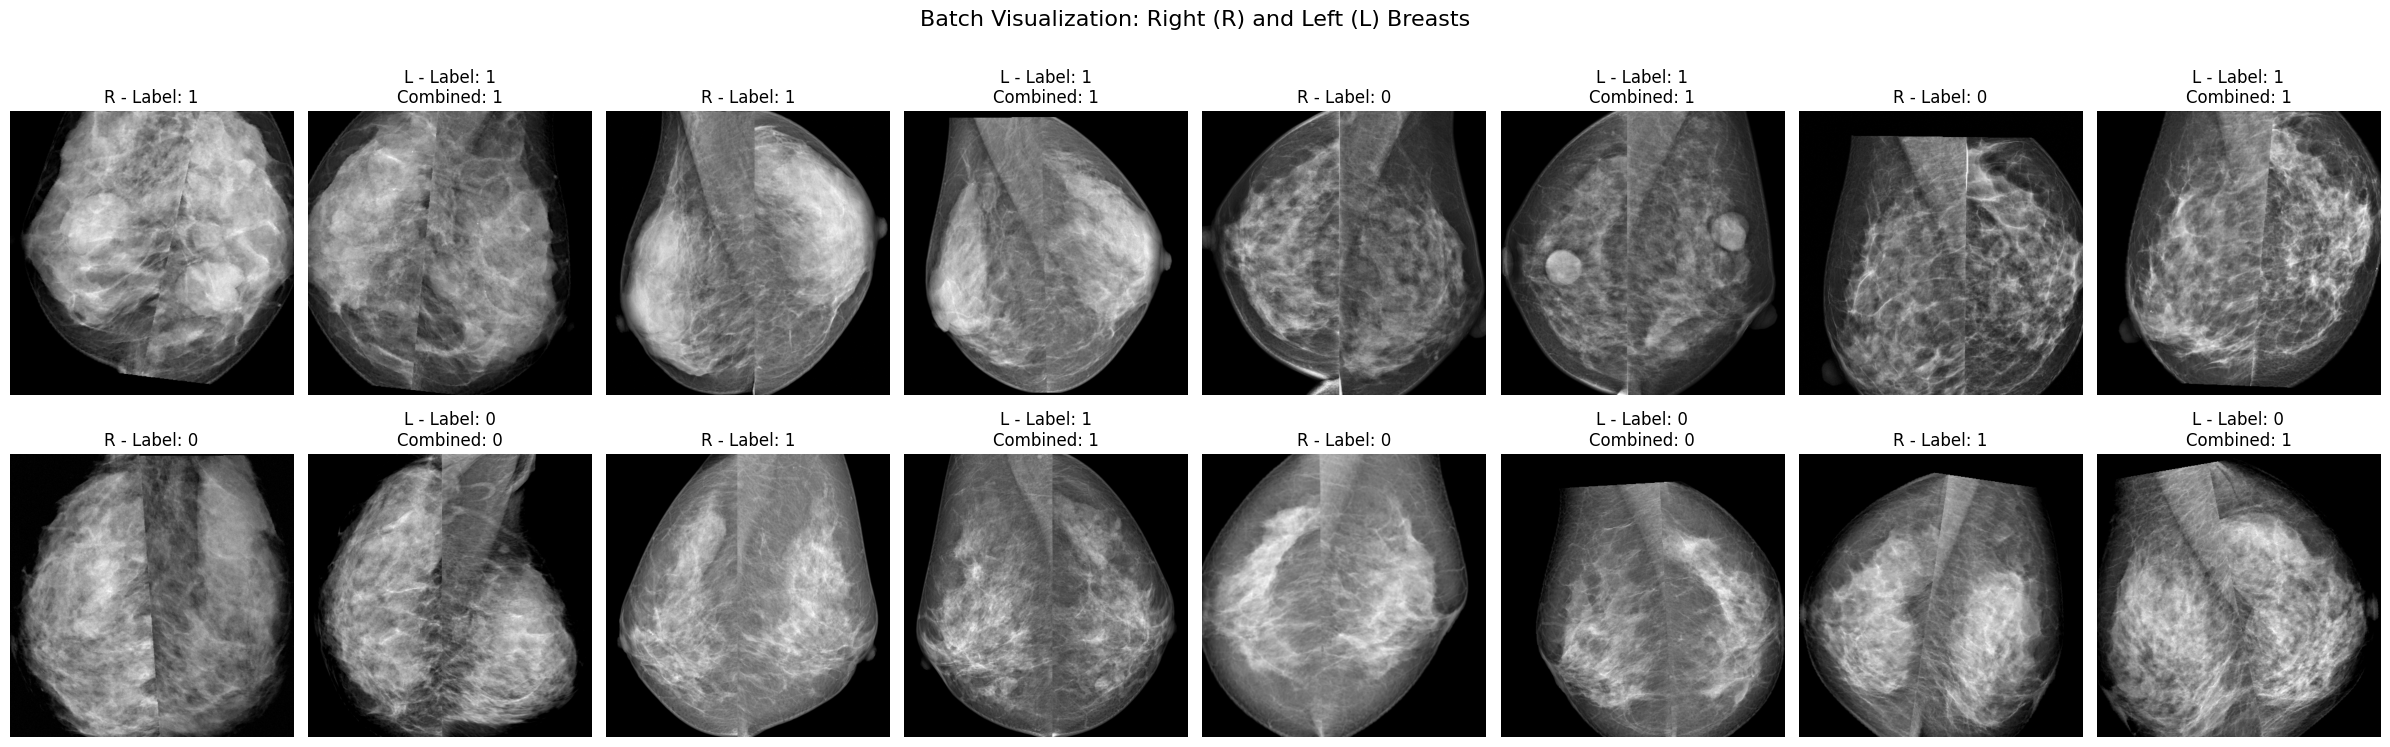


Visualizing validation samples (paired R/L breasts):


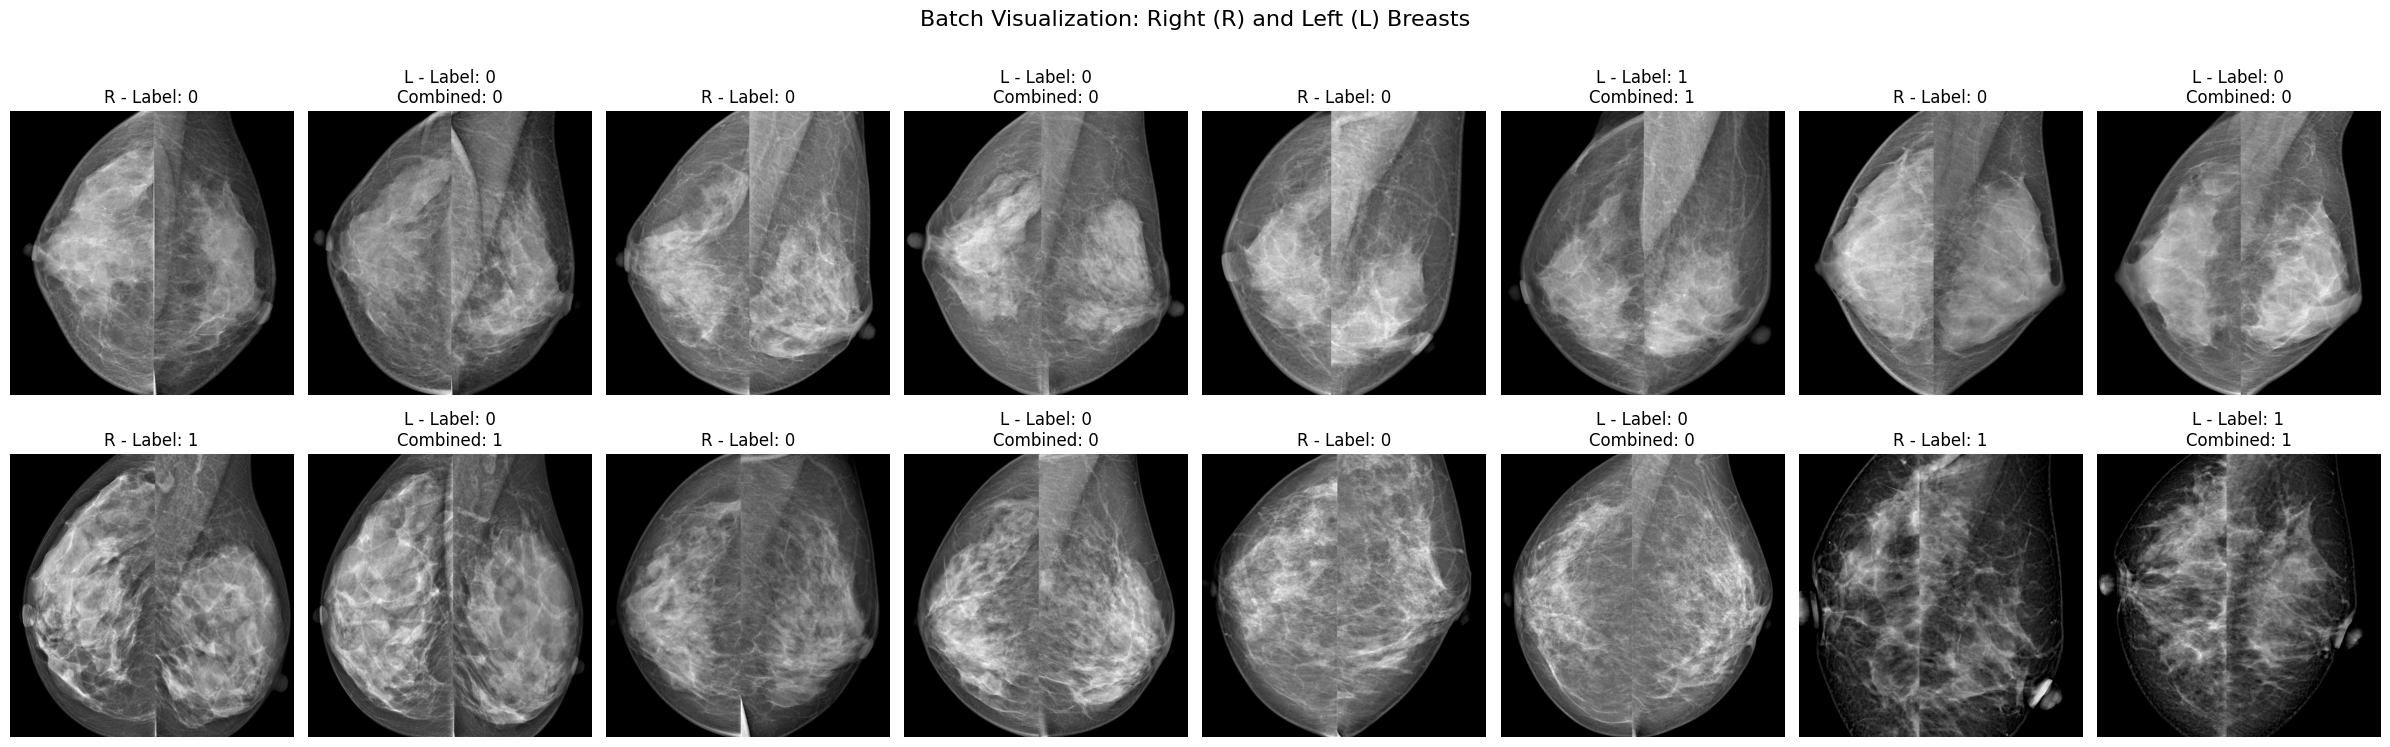

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_batch(batch, n_cols=4, apply_inverse_normalize=True):
    """
    Visualize a batch from the updated paired-breast dataset.
    Each sample contains: (image_R, image_L, label_R, label_L, combined_label, finding, density)
    We display R and L breasts side-by-side for each patient, with individual and combined labels.
    """
    image_R, image_L, label_R, label_L, combined_label, finding, density = batch
    
    batch_size = image_R.shape[0]
    # 2 images per patient (R and L) -> 2 * n_cols images per row
    images_per_row = 2 * n_cols
    n_rows = int(np.ceil(batch_size / n_cols))
    
    fig, axes = plt.subplots(n_rows, images_per_row, figsize=(3 * images_per_row, 4 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]  # Ensure 2D for consistency
    axes = axes.reshape(n_rows, images_per_row)
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i in range(batch_size):
        row = i // n_cols
        col_offset = 2 * (i % n_cols)
        
        # Process Right breast
        img_R = image_R[i].permute(1, 2, 0).cpu().numpy()
        if apply_inverse_normalize:
            img_R = img_R * std + mean
        img_R = img_R.clip(0, 1)
        img_R_gray = img_R.mean(axis=2)  # Convert to grayscale for mammography display
        
        axes[row, col_offset].imshow(img_R_gray, cmap='gray')
        axes[row, col_offset].set_title(f"R - Label: {label_R[i].item()}")
        axes[row, col_offset].axis('off')
        
        # Process Left breast
        img_L = image_L[i].permute(1, 2, 0).cpu().numpy()
        if apply_inverse_normalize:
            img_L = img_L * std + mean
        img_L = img_L.clip(0, 1)
        img_L_gray = img_L.mean(axis=2)
        
        axes[row, col_offset + 1].imshow(img_L_gray, cmap='gray')
        title = f"L - Label: {label_L[i].item()}\nCombined: {combined_label[i].item()}"
        axes[row, col_offset + 1].set_title(title)
        axes[row, col_offset + 1].axis('off')
    
    # Hide any unused subplots
    total_subplots = n_rows * images_per_row
    for j in range(2 * batch_size, total_subplots):
        r, c = divmod(j, images_per_row)
        axes[r, c].axis('off')
    
    plt.suptitle("Batch Visualization: Right (R) and Left (L) Breasts", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Visualize training batch
print("Visualizing training samples (paired R/L breasts):")
train_batch = next(iter(train_loader))
visualize_batch(train_batch)

# Visualize validation batch
print("\nVisualizing validation samples (paired R/L breasts):")
val_batch = next(iter(val_loader))
visualize_batch(val_batch)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class MammoDualViewModel(nn.Module):
    def __init__(self, backbone_class, backbone_weights=None, num_classes=5, feature_dim=512, dropout=0.3):
        super().__init__()
        
        self.shared_backbone = backbone_class(weights=backbone_weights)
        self.extractor, num_features = self._get_feature_extractor(self.shared_backbone)
        
        self.classifier = nn.Sequential(
            nn.Linear(num_features * 2, 512),
            nn.BatchNorm1d(512),  
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout/2),
            
            nn.Linear(256, num_classes)
        )
    def _get_feature_extractor(self, model):
        if hasattr(model, "classifier") and hasattr(model.classifier, "in_features"):
            num_features = model.classifier.in_features
            model.classifier = nn.Identity()
            return model, num_features
        
        if hasattr(model, "classifier") and isinstance(model.classifier, nn.Sequential):
            num_features = model.classifier[-1].in_features
            model.classifier = nn.Identity()
            return model, num_features
        
        if hasattr(model, "fc"):
            num_features = model.fc.in_features
            model.fc = nn.Identity()
            return model, num_features
        
        if hasattr(model, "classifier") and hasattr(model, "features"):
            num_features = model.classifier.in_features
            model.classifier = nn.Identity()
            return model, num_features
        
        if hasattr(model, "head"):
            num_features = model.head.in_features
            model.head = nn.Identity()
            return model, num_features
        
        raise ValueError("Unsupported backbone architecture.")
    
    def forward(self, left, right):
        left_feat = self.extractor(left)
        right_feat = self.extractor(right)
        
        if left_feat.dim() == 4:
            left_feat = left_feat.mean([-2, -1])
        if right_feat.dim() == 4:
            right_feat = right_feat.mean([-2, -1])
        
        combined = torch.cat([left_feat, right_feat], dim=1)
        logits = self.classifier(combined)
        
        return logits

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

models_config = [
    {
        'name': 'efficientnet_b3',
        'class': models.efficientnet_b3,
        'weights': models.EfficientNet_B3_Weights.DEFAULT
    },
    {
        'name': 'convnext_base',
        'class': models.convnext_base,
        'weights': models.ConvNeXt_Base_Weights.DEFAULT
    },
]


def save_results(report, cm, save_path, dataset_name):
    os.makedirs(save_path, exist_ok=True)
    
    # Save classification report
    report_path = os.path.join(save_path, f"{dataset_name}_classification_report.txt")
    with open(report_path, "w") as f:
        f.write(report)
    
    # Save confusion matrix as PNG
    cm_path = os.path.join(save_path, f"{dataset_name}_confusion_matrix.png")
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                xticklabels=['Normal', 'Malignant'], 
                yticklabels=['Normal', 'Malignant'])
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    plt.close()


class AsymmetricFocalLoss(nn.Module):
    def __init__(
        self,
        gamma_neg: float = 1.0,  # benign
        gamma_pos: float = 3.0,  # malignant
        alpha: float = 0.75,     # weight for malignant
        eps: float = 1e-8
    ):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.alpha = alpha
        self.eps = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss).clamp(min=self.eps, max=1.0)
        gamma = torch.where(targets == 1, self.gamma_pos, self.gamma_neg)
        alpha_t = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        loss = alpha_t * (1.0 - pt) ** gamma * ce_loss
        return loss.mean()
        

class EarlyStopper:
    def __init__(self, patience=25, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
    
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        if score < self.best_score + self.min_delta:
            self.counter += 1
            return self.counter >= self.patience
        self.best_score = score
        self.counter = 0
        return False


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    preds_all, labels_all, probs_all = [], [], []
    
    with torch.set_grad_enabled(train):
        for batch in loader:
            right_view, left_view, _, _, combined_label, _, _ = batch
            right_view = right_view.to(device, non_blocking=True)
            left_view = left_view.to(device, non_blocking=True)
            labels = combined_label.to(device, non_blocking=True)
            
            if train and scaler is not None:
                # Mixed precision training
                with torch.amp.autocast('cuda'):
                    outputs = model(right_view, left_view)
                    loss = criterion(outputs, labels)
                
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                # Regular forward pass (validation/test or no scaler)
                outputs = model(right_view, left_view)
                loss = criterion(outputs, labels)
                
                if train and optimizer is not None:
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
            
            total_loss += loss.item() * right_view.size(0)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            preds_all.extend(preds.detach().cpu().numpy())
            labels_all.extend(labels.detach().cpu().numpy())
            probs_all.extend(probs[:, 1].detach().cpu().numpy())
    
    num_samples = len(loader.dataset)
    avg_loss = total_loss / num_samples
    preds_np = np.array(preds_all)
    labels_np = np.array(labels_all)
    probs_np = np.array(probs_all)
    acc = np.mean(preds_np == labels_np) * 100
    f1_macro = f1_score(labels_np, preds_np, average='macro', zero_division=0)
    f1_pos = f1_score(labels_np, preds_np, average='binary', pos_label=1, zero_division=0)
    auc = roc_auc_score(labels_np, probs_np) if len(np.unique(labels_np)) > 1 else 0.5
    report = classification_report(labels_np, preds_np, target_names=['Normal', 'Malignant'], zero_division=0)
    cm = confusion_matrix(labels_np, preds_np)
    return avg_loss, acc, f1_macro, f1_pos, auc, report, cm


def train_and_evaluate(model_name, backbone_class, backbone_weights, train_loader, val_loader, test_loader, inbreast_loader):
    model = MammoDualViewModel(backbone_class, backbone_weights).to(device)
    criterion = AsymmetricFocalLoss(
        gamma_neg=1.5,   
        gamma_pos=1.0,    
        alpha=0.5     
    )
    optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8, min_lr=1e-6)
    stopper = EarlyStopper(patience=15, min_delta=0.001)
    
    # Initialize GradScaler for mixed precision training
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
    
    save_dir = f"Thesis_updated_results/4_view_binary_512/{model_name}"
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, "best_model.pth")
    best_f1 = 0.0
    epochs = 60
    
    for epoch in range(epochs):
        train_loss, train_acc, train_f1, _, _, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, scaler, train=True
        )
        val_loss, val_acc, val_f1, val_f1_pos, val_auc, val_report, val_cm = run_epoch(
            model, val_loader, criterion, train=False
        )
        scheduler.step(val_f1)
        
        print(f"\nEpoch {epoch+1:2d}/{epochs} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"Train: Loss={train_loss:.4f} | F1={train_f1:.3f} | Acc={train_acc:.1f}%")
        print(f"Val:   Loss={val_loss:.4f} | F1={val_f1:.3f} | F1+={val_f1_pos:.3f} | AUC={val_auc:.3f}")
        print(f"Val CM:\n{val_cm}")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save({'model_state_dict': model.state_dict()}, best_model_path)
            print(f"New best model saved (F1: {val_f1:.3f})")
        
        if stopper(val_f1):
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print("\nFINAL EVALUATION")
    for loader, name in [(test_loader, "VinDr-Test"), (inbreast_loader, "InBreast-Test")]:
        loss, acc, f1, f1_pos, auc, report, cm = run_epoch(model, loader, criterion, train=False)
        dataset_folder = "vindr" if "VinDr" in name else "inbreast"
        save_results(report, cm, os.path.join(save_dir, dataset_folder), name)
        print(f"\n{model_name.upper()} | {name}")
        print(f"Loss: {loss:.4f} | Acc: {acc:.1f}% | F1: {f1:.3f} | F1+: {f1_pos:.3f} | AUC: {auc:.3f}")
        print(f"CM:\n{cm}")
    
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


if __name__ == "__main__":
    for cfg in models_config:
        train_and_evaluate(
            cfg['name'],
            cfg['class'],
            cfg['weights'],
            train_loader,
            val_loader,
            test_loader,
            inbreast_loader
        )

Using device: cuda

Epoch  1/60 | LR: 1.00e-05
Train: Loss=0.1291 | F1=0.340 | Acc=51.0%
Val:   Loss=0.1266 | F1=0.335 | F1+=0.670 | AUC=0.545
Val CM:
[[  0 198]
 [  0 201]]
New best model saved (F1: 0.335)

Epoch  2/60 | LR: 1.00e-05
Train: Loss=0.1263 | F1=0.337 | Acc=50.9%
Val:   Loss=0.1262 | F1=0.335 | F1+=0.670 | AUC=0.572
Val CM:
[[  0 198]
 [  0 201]]

Epoch  3/60 | LR: 1.00e-05
Train: Loss=0.1254 | F1=0.329 | Acc=49.1%
Val:   Loss=0.1242 | F1=0.335 | F1+=0.670 | AUC=0.605
Val CM:
[[  0 198]
 [  0 201]]

Epoch  4/60 | LR: 1.00e-05
Train: Loss=0.1218 | F1=0.336 | Acc=50.6%
Val:   Loss=0.1166 | F1=0.335 | F1+=0.670 | AUC=0.675
Val CM:
[[  0 198]
 [  0 201]]

Epoch  5/60 | LR: 1.00e-05
Train: Loss=0.1175 | F1=0.342 | Acc=51.9%
Val:   Loss=0.1097 | F1=0.335 | F1+=0.670 | AUC=0.731
Val CM:
[[  0 198]
 [  0 201]]

Epoch  6/60 | LR: 1.00e-05
Train: Loss=0.1137 | F1=0.344 | Acc=51.6%
Val:   Loss=0.1089 | F1=0.335 | F1+=0.670 | AUC=0.742
Val CM:
[[  0 198]
 [  0 201]]

Epoch  7/60 | LR: